In [3]:
import os
import sys
import json
import random
import pandas as pd
import numpy as np
import cv2
import shutil
import timm
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from pathlib import Path

SRC_DIR = (Path.cwd() / '../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = (Path.cwd() / '../data').resolve()
assert DATA_DIR.exists(), f"data 폴더를 찾지 못했습니다: {DATA_DIR}"
print(f"DATA_DIR: {DATA_DIR}")

DATA_DIR: /home/vsc/LLM_TUNE/structure-stability/data


In [4]:
# 1. 데이터 로드
train_df = pd.read_csv(DATA_DIR / 'train.csv', encoding='utf-8-sig')
val_df = pd.read_csv(DATA_DIR / 'dev.csv', encoding='utf-8-sig')

print(f"학습 데이터 개수: {len(train_df)}")
print(f"검증 데이터 개수: {len(val_df)}")

학습 데이터 개수: 1000
검증 데이터 개수: 100


In [5]:
DATA_DIR     = Path('../data').resolve()
TRAIN_ROOT   = DATA_DIR / 'train'
FEATURE_DIR  = DATA_DIR / 'videomae_features'   # feature 저장 경로
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME   = '/home/vsc/LLM/model/videomae-base-finetuned-kinetics'
NUM_FRAMES   = 16       # VideoMAE 입력 프레임 수 (고정)
FRAME_SIZE   = 224      # VideoMAE 입력 해상도 (고정)
BATCH_SIZE   = 4        # 한 번에 처리할 비디오 수 (VRAM에 따라 조정)
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

특징 데이터 로드 중...
t-SNE 계산 중 (시간이 다소 소요될 수 있습니다)...


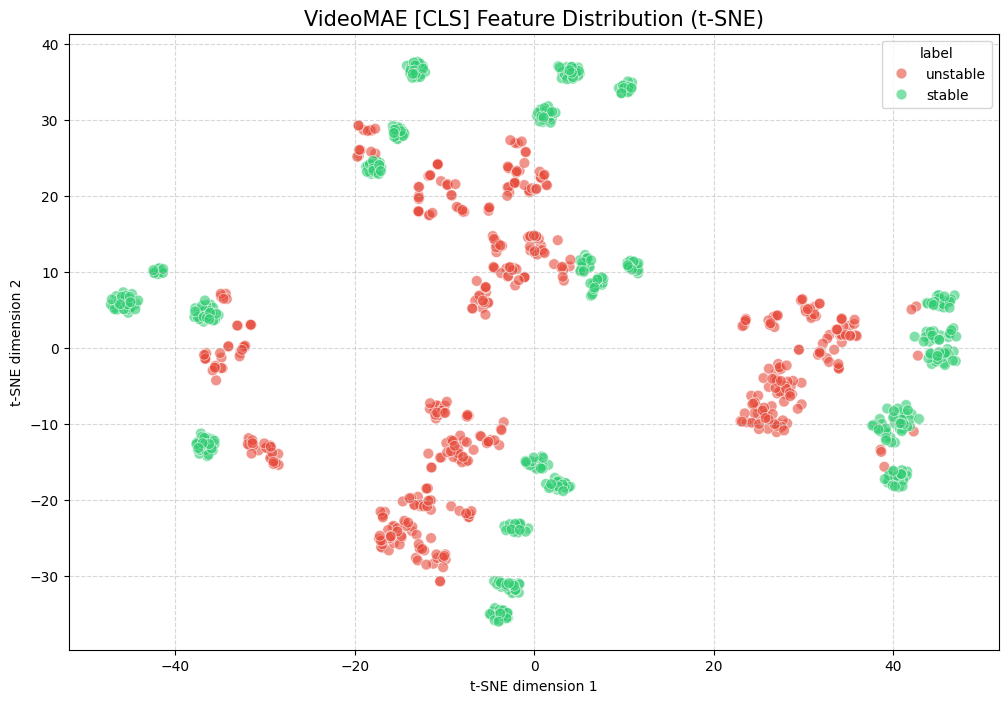

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE # 고차원 데이터를 저차원 공간으로 시각화 하기 위해 사용하는 비선형 차원축소 기법
from sklearn.preprocessing import StandardScaler

def visualize_feature_distribution(train_df, feature_dir):
    """
    저장된 .npy 특징들을 로드하여 t-SNE 시각화를 수행합니다.
    """
    features = []
    labels = []
    valid_ids = []

    print("특징 데이터 로드 중...")
    for _, row in train_df.iterrows():
        sid = str(row['id'])
        feat_path = Path(feature_dir) / f"{sid}.npy"
        
        if feat_path.exists():
            feat = np.load(feat_path)
            features.append(feat)
            labels.append(row['label']) # 'stable' or 'unstable'
            valid_ids.append(sid)

    features = np.array(features) # (N, 768)
    
    # 1. 표준화 (t-SNE 전 필수 단계)
    features_scaled = StandardScaler().fit_transform(features)

    # 2. t-SNE 수행
    print("t-SNE 계산 중 (시간이 다소 소요될 수 있습니다)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(features_scaled)

    # 3. 데이터프레임 구축
    df_tsne = pd.DataFrame({
        'x': tsne_results[:, 0],
        'y': tsne_results[:, 1],
        'label': labels
    })

    # 4. 시각화
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x='x', y='y',
        hue='label',
        palette={'stable': '#2ecc71', 'unstable': '#e74c3c'},
        data=df_tsne,
        alpha=0.6,
        edgecolor='w',
        s=60
    )
    plt.title('VideoMAE [CLS] Feature Distribution (t-SNE)', fontsize=15)
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 사용 예시
visualize_feature_distribution(train_df, FEATURE_DIR)

데이터 로딩 및 분석 중...

🚀 [결과 1] 평균 Intensity가 가장 높은 인덱스 (Top 5)
순위 1: Index 307 (평균값: 222.4902)
순위 2: Index 761 (평균값: 14.4765)
순위 3: Index 284 (평균값: 11.9446)
순위 4: Index 31 (평균값: 11.7895)
순위 5: Index 13 (평균값: 11.1577)

⚖️ [결과 2] Stable/Unstable 차이가 가장 큰 인덱스 (Top 5)
순위 1: Index 307 (차이: 2.1115)
순위 2: Index 611 (차이: 1.0532)
순위 3: Index 61 (차이: 1.0250)
순위 4: Index 113 (차이: 0.9958)
순위 5: Index 73 (차이: 0.9106)


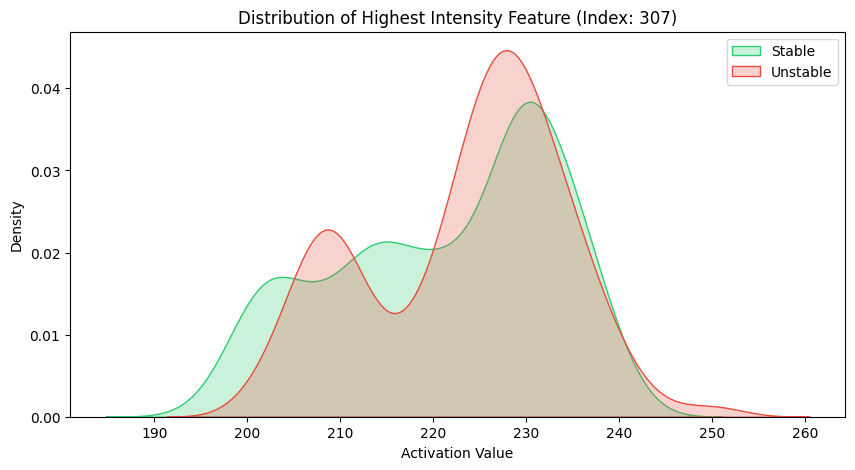

In [10]:
def analyze_top_active_features(train_df, feature_dir, top_n=5):
    """
    모든 샘플에서 평균적으로 가장 강하게 활성화되는 특징 인덱스를 찾습니다.
    """
    all_features = []
    labels = []
    
    print("데이터 로딩 및 분석 중...")
    for _, row in train_df.iterrows():
        sid = str(row['id'])
        path = Path(feature_dir) / f"{sid}.npy"
        if path.exists():
            all_features.append(np.load(path))
            labels.append(row['label'])
            
    features = np.array(all_features) # (N, 768)
    labels = np.array(labels)
    
    # 1. 글로벌 평균 활성도 계산 (단순히 값이 가장 큰 인덱스)
    mean_activations = np.mean(features, axis=0)
    top_indices = np.argsort(mean_activations)[::-1][:top_n]
    
    # 2. 클래스별 차이 계산 (Stable vs Unstable 차이가 큰 인덱스)
    stable_mean = np.mean(features[labels == 'stable'], axis=0)
    unstable_mean = np.mean(features[labels == 'unstable'], axis=0)
    diff = np.abs(stable_mean - unstable_mean)
    top_diff_indices = np.argsort(diff)[::-1][:top_n]

    print("\n" + "="*50)
    print(f"🚀 [결과 1] 평균 Intensity가 가장 높은 인덱스 (Top {top_n})")
    for i, idx in enumerate(top_indices):
        print(f"순위 {i+1}: Index {idx} (평균값: {mean_activations[idx]:.4f})")
        
    print("\n" + "="*50)
    print(f"⚖️ [결과 2] Stable/Unstable 차이가 가장 큰 인덱스 (Top {top_n})")
    for i, idx in enumerate(top_diff_indices):
        print(f"순위 {i+1}: Index {idx} (차이: {diff[idx]:.4f})")
    print("="*50)

    # 시각화: 가장 강한 특징의 분포 확인
    best_idx = top_indices[0]
    plt.figure(figsize=(10, 5))
    sns.kdeplot(features[labels == 'stable'][:, best_idx], label='Stable', fill=True, color='#2ecc71')
    sns.kdeplot(features[labels == 'unstable'][:, best_idx], label='Unstable', fill=True, color='#e74c3c')
    plt.title(f"Distribution of Highest Intensity Feature (Index: {best_idx})")
    plt.xlabel("Activation Value")
    plt.legend()
    plt.show()

# 실행
analyze_top_active_features(train_df, FEATURE_DIR)

In [11]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def run_feature_logistic_regression(train_df, feature_dir, target_indices=None):
    """
    VideoMAE 특징을 사용하여 Logistic Regression을 수행합니다.
    
    Args:
        train_df: 'id'와 'label' 컬럼이 포함된 데이터프레임
        feature_dir: .npy 파일들이 저장된 경로
        target_indices: 특정 인덱스만 사용할 경우 리스트 (None이면 전체 768개 사용)
    """
    features = []
    labels = []
    
    print(f"데이터 로드 중... (Target Indices: {target_indices if target_indices else 'ALL'})")
    
    for _, row in train_df.iterrows():
        sid = str(row['id'])
        feat_path = Path(feature_dir) / f"{sid}.npy"
        
        if feat_path.exists():
            feat = np.load(feat_path)
            # 특정 인덱스만 필터링
            if target_indices is not None:
                feat = feat[target_indices]
            
            features.append(feat)
            # 사용자 요청 매핑: unstable -> 0, stable -> 1
            labels.append(1 if row['label'] == 'stable' else 0)

    X = np.array(features)
    y = np.array(labels)

    # 1. 데이터 분할 (8:2)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 2. 표준화 (Logistic Regression은 스케일에 민감함)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # 3. 모델 정의 및 학습
    # 가중치 규제(C)와 최대 반복 횟수를 넉넉히 설정
    model = LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs')
    model.fit(X_train_scaled, y_train)

    # 4. 예측 및 평가
    y_pred = model.predict(X_val_scaled)
    y_prob = model.predict_proba(X_val_scaled) # LogLoss 계산용 확률

    acc = accuracy_score(y_val, y_pred)
    loss = log_loss(y_val, y_prob)

    print("\n" + "="*50)
    print(f"📊 [결과 보고서] 특징 수: {X.shape[1]}개")
    print(f"✅ Accuracy: {acc:.4f}")
    print(f"📉 LogLoss : {loss:.4f}")
    print("="*50)
    
    # 5. 혼동 행렬 시각화
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['unstable(0)', 'stable(1)'], 
                yticklabels=['unstable(0)', 'stable(1)'])
    plt.title(f"Confusion Matrix (Features: {X.shape[1]})")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return model, acc

--- [실험 1: 핵심 1개 특징만 사용] ---
데이터 로드 중... (Target Indices: [307])

📊 [결과 보고서] 특징 수: 1개
✅ Accuracy: 0.5700
📉 LogLoss : 0.6916


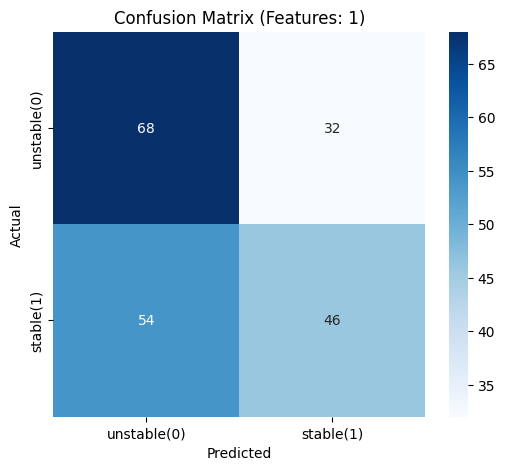

--- [실험 2: 307번 제거 후 나머지 767개로 학습] ---
데이터 로드 중... (Target Indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 2

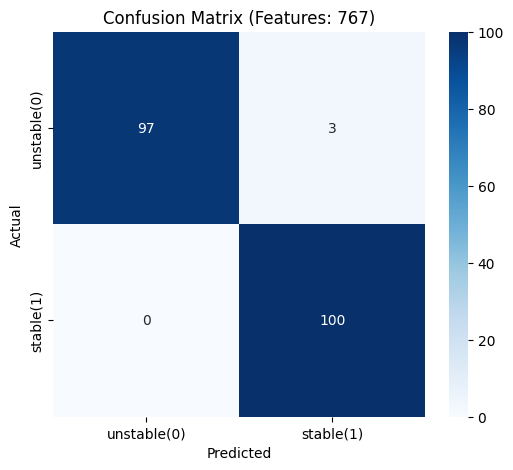


--- [실험 3: 전체 768개 특징 사용] ---
데이터 로드 중... (Target Indices: ALL)

📊 [결과 보고서] 특징 수: 768개
✅ Accuracy: 0.9850
📉 LogLoss : 0.0312


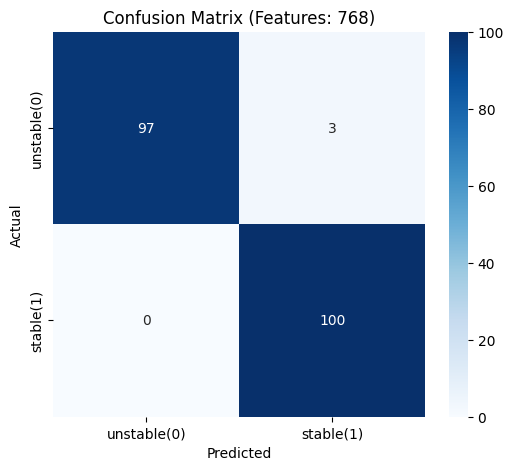

In [15]:
# 1) 우리가 찾은 Top 5 차이 인덱스만 사용하여 실행
top_indices = [307]
print("--- [실험 1: 핵심 1개 특징만 사용] ---")
model_top, acc_top = run_feature_logistic_regression(train_df, FEATURE_DIR, target_indices=top_indices)

# 307번을 제외한 모든 인덱스 생성
all_indices = list(range(768))
all_indices.remove(307)
print("--- [실험 2: 307번 제거 후 나머지 767개로 학습] ---")
model_no_307, acc_no_307 = run_feature_logistic_regression(train_df, FEATURE_DIR, target_indices=all_indices)

# 2) 전체 768개 특징을 사용하여 실행
print("\n--- [실험 3: 전체 768개 특징 사용] ---")
model_all, acc_all = run_feature_logistic_regression(train_df, FEATURE_DIR, target_indices=None)